# Empirical Finance - 20999

# Lab 4: On the (non-) normality of returns

In this lab, we study the unconditional distribution of the log returns examined in Lab 3.

Specifically, we focus on the daily log returns of Bank of America Corporation over a 10-year period spanning 2014-2024.

In particular, we analyze whether the normality assumption for log returns, implied by the common Gaussian extension of the Log Random Walk model, is empirically sound.

In [1]:
from datetime import date
import yfinance as yf
import numpy as np

myStart = date(2014, 12 ,31)
myEnd = date(2024, 12, 31)


myTicker = "BAC"

prices = yf.download(myTicker, myStart, myEnd)
prices = prices.droplevel(1, axis=1)
prices = prices.drop(columns=["High", "Low", "Open", "Volume"])
prices = prices.rename(columns={prices.columns[0]: "AP"})

r_df = np.log(prices/prices.shift(1))
r_df = r_df.dropna()
r = r_df.to_numpy()

/tmp/ipykernel_34230/572245309.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(myTicker, myStart, myEnd)
[*********************100%***********************]  1 of 1 completed


The NumPy array `r` contains the sample of interest, $\{ r^*_{t-i} \}_{i=0}^{n-1}$, which we regard as $n$ independent realizations of the same random variable $r^*$. Hence, we assume an ideal i.i.d. sample of daily log returns to study.

When analyzing the distribution of a given variable, it is convenient to do so in standardized terms to avoid confounding effects due to differences in scale. Therefore, we first construct a standardized sample $\{ x_i \}_{i=0}^{n-1}$,where, for any $i$,  
$$x_i = \frac{r_{t-i}^* - \bar{r}^*}{\sqrt{S^2}},$$  
and where $\bar{r}^*$ and $\sqrt{S^2}$ denote the sample mean and standard deviation of the original sample.

In [2]:
n = len(r)

In [3]:
mu = np.mean(r)
sigma = np.std(r)

x = (r -mu)/sigma

In [4]:
x.mean()

np.float64(-1.271348831379901e-17)

In [5]:
x.var()

np.float64(1.0)

We begin by analyzing the higher-order moments of the empirical distribution of the log returns, namely skewness and kurtosis.

Skewness, defined as  
$$\text{skew}[X] = \text{E} \left[ \left( \frac{X - \text{E}[X]}{\text{st.d}[X]} \right)^3 \right],$$  
is the third standardized central moment of a distribution and measures its asymmetry.

For our sample of log returns $\{ r^*_{t-i} \}_i$, a naive sample estimator of skewness is  
$$\hat{\text{skew}}[r_t^*] = \frac{1}{n} \sum_{i=0}^{n-1} \left( \frac{r_{t-i}^* - \bar{r}^*}{\sqrt{S^2}} \right)^3,$$  
or, equivalently, when using the standardized sample $\{ x_i \}_i$,  
$$\hat{\text{skew}}[X] = \frac{1}{n} \sum_{i=0}^{n-1} x_i^3.$$

The benchmark value for any normal distribution is $0$, that is,  
$$\text{skew}[\mathcal{N}(\mu, \sigma^2)] = 0.$$

In [6]:
my_skew = np.mean( ((r-np.mean(r))/np.std(r))**3 )
my_skew

np.float64(-0.02542734993230586)

In [7]:
my_skew = np.mean( x**3 )
my_skew

np.float64(-0.02542734993230586)

Of course, `scipy.stats` provides a built-in function to compute the sample skewness, as well as its unbiased version that, for sake of completeness, reads
$$\hat{\text{skew}}_{unbiased}[r_t^*] = \frac{\sqrt{n(n-1)}}{n(n-2)} \sum_{i=0}^{n-1} \left( \frac{r_{t-i}^* - \bar{r}^*}{\sqrt{S^2}} \right)^3.$$  

In [8]:
from scipy.stats import skew

sample_skew = skew(x)
sample_skew

array([-0.02542735])

In [9]:
unbiased_skew = skew(x, bias = False)
unbiased_skew

array([-0.02544253])

In [10]:
unbiased_skew = np.sqrt(n*(n-1))/(n*(n-2))*np.sum( ((r-np.mean(r))/np.std(r))**3 )
unbiased_skew

np.float64(-0.025442526916333853)

In [11]:
print(
    f"Sample skewness (biased)   : {sample_skew[0]:.6f}\n"
    f"Sample skewness (unbiased) : {unbiased_skew:.6f}"
)

Sample skewness (biased)   : -0.025427
Sample skewness (unbiased) : -0.025443


As expected, the log returns are left-skewed, exhibiting a mild negative skew. This indicates that the left tail of the distribution is longer or heavier than the right tail, meaning that extreme negative events are more likely than extreme positive ones.

We now turn to kurtosis, the standardized fourth central moment, defined as  
$$\text{kurt}[X] = \text{E} \left[ \left( \frac{X - \text{E}[X]}{\text{st.d}[X]} \right)^4 \right],$$  
which measures the fatness of the distribution's tails and the sharpness of its peak.

A naive sample estimator applied to our sample of log returns $\{ r^*_{t-i} \}_i$ is given by  
$$\hat{\text{kurt}}[r_t^*] = \frac{1}{n} \sum_{i=0}^{n-1} \left( \frac{r_{t-i}^* - \bar{r}^*}{\sqrt{S^2}} \right)^4,$$  
or, equivalently, when using the standardized sample $\{ x_i \}_i$,  
$$\hat{\text{kurt}}[X] = \frac{1}{n} \sum_{i=0}^{n-1} x_i^4.$$
The benchmark value for any normal distribution is $3$, that is,  
$$\text{kurtosis}[\mathcal{N}(\mu, \sigma^2)] = 3.$$

In [12]:
my_kurt = np.mean( x**4 )
my_kurt

np.float64(12.608446132291682)

As with skewness, `scipy.stats` provides a built-in function to estimate kurtosis, both in its biased and unbiased forms. The function actually returns the *excess kurtosis*, that is, the kurtosis in excess of the normal benchmark,  
$$\text{ex.kurt}[X] = \text{kurt}[X] - 3.$$

In [13]:
from scipy.stats import kurtosis

sample_kurt = kurtosis(x)
sample_kurt+3

array([12.60844613])

In [14]:
unbiased_kurt = kurtosis(x, bias = False)
unbiased_kurt+3

array([12.62996528])

As expected, the log returns are leptokurtic, displaying a markedly positive kurtosis (or an excess kurtosis well above $3$), indicating that the empirical distribution once again exhibits fat tails and a sharp peak.

We now turn to the analysis of the full empirical distribution of the log returns under consideration. We begin with some simple computations comparing the observed frequencies of certain events with their theoretical probabilities under the normality assumption, following the approach of Examples 4.6-4.8 in the Lecture Notes.

We start by examining the probability of observing "extreme returns" (see Example 4.6).

In particular, we focus on returns smaller than $-5$ standard deviations and compare the empirical probability of this event (estimated as a simple frequency) with the theoretical probability under the normality assumption, which is simply given by $\Phi(-5)$.

In [15]:
x0 = -5

np.sum( x <= x0 )

np.int64(4)

In [16]:
F_hat_x0 = np.sum( x <= x0 )/n
F_hat_x0

np.float64(0.0015904572564612327)

In [17]:
F_hat_x0 = np.mean( x <= x0 )
F_hat_x0

np.float64(0.0015904572564612327)

In [18]:
from scipy.stats import norm

Phi_x0 = norm.cdf(x0)
Phi_x0

np.float64(2.866515718791933e-07)

In [19]:
F_hat_x0/Phi_x0

np.float64(5548.398866382343)

As we saw, the empirical probability, namely, the actual frequency of these ``extreme'' negative returns occurring, is thousands of times larger than what would be implied by the normality assumption.

However, when considering, for example, a Student-$t$ distribution with $3$ degrees of freedom, this ratio becomes dramatically closer to $1$, suggesting that this distribution is better suited to describe the likelihood of such ``extreme'' events.

In [20]:
from scipy.stats import t

F_t3 = t(3).cdf(x0)
F_t3

np.float64(0.007696219036651148)

In [21]:
F_hat_x0/F_t3

np.float64(0.20665436481044952)

Of course, as we move away from the tails of the distribution, the normal distribution tends to provide increasingly reasonable probability estimates.

In [22]:
x0 = 0

F_hat_x0 = np.sum( x <= x0 )/n
Phi_x0 = norm.cdf(x0)

print(
    f"The frequency of returns smaller than {x0} standard deviations "
    f"is F̂({x0}) = {F_hat_x0:.6f}, "
    f"while the probability of the same event under normality "
    f"is Φ({x0}) = {Phi_x0:.6f}.\n"
    f"Therefore, the empirical frequency is {F_hat_x0 / Phi_x0:.2f} times "
    f"the theoretical one."
)

The frequency of returns smaller than 0 standard deviations is F̂(0) = 0.502584, while the probability of the same event under normality is Φ(0) = 0.500000.
Therefore, the empirical frequency is 1.01 times the theoretical one.


Analogously, we can focus on the probability of returns falling within a given interval, such as between $-1$ and $+1$ standard deviations (see Example 4.8), which corresponds to "moderate" returns.

In [23]:
l_x = -1
u_x = 1

F_hat_interval = (np.sum( x <= u_x) - np.sum( x <= l_x ))/n
F_hat_interval

np.float64(0.7868787276341949)

In [24]:
(1 < 2) and (3 < 5)

True

In [25]:
(1 < 2) & (7 < 5)

False

In [26]:
(1 < 2) or (7 < 5)

True

In [27]:
(4 < 2) | (7 < 5)

False

In [28]:
(4 < 2) | (7 < 5) | (10 == 10)

True

In [29]:
F_hat_interval = np.sum((l_x <= x) & (x <= u_x))/n
F_hat_interval

np.float64(0.7868787276341949)

In [30]:
Phi_interval = norm.cdf(u_x)-norm.cdf(l_x)
Phi_interval

np.float64(0.6826894921370859)

Moving forward, we can compute the theoretical probability of observing either exactly $k$ returns within a given interval, or at least $k$ such returns, out of an $n$-dimensional sample of i.i.d. standard normal variables.

To this end, fix a threshold $L$ and let $N$ denote the random variable representing the number of returns (out of the $n$ i.i.d. ones) that take a value smaller than $L$. Let $p$ be the probability that a single observation is smaller than $L$. In this case, $N$ follows a binomial distribution counting the number of "successes" in $n$ independent trials, each with probability of success $p$.

Formally, the support of $N$ is $\{0, 1, \dots, n\}$, and its probability mass function is  
$$\Pr[N = k] = \binom{n}{k} p^k (1 - p)^{n - k},$$  
where the binomial coefficient $\binom{n}{k}$ is defined as  
$$\binom{n}{k} = \frac{n!}{(n - k)! \, k!},$$  
and $n!$ denotes the factorial of $n$, that is, $n! = \prod_{i=1}^n i$, with $0! = 1$.

Beware: within `scipy`, the module `scipy.special` provides the function `binom`, which computes the binomial coefficient, whereas in `scipy.stats`, the object `binom` refers to the binomial random variable. To avoid confusion between these two distinct objects sharing the same name, it is preferable to use the function `comb` from `scipy.special` when computing binomial coefficients.


In [31]:
from scipy.special import comb
from scipy.stats import binom

comb(5,2)

np.float64(10.0)

In [32]:
type(binom)

scipy.stats._discrete_distns.binom_gen

Let us start with the probability, under the normality assumption, of observing exactly as many ``extreme returns'' (below $-5$ standard deviations) as those observed in the sample.

In [33]:
x0 = -5

k = np.sum( x <= x0 )
k

np.int64(4)

In [34]:
p = norm.cdf(x0)
p

np.float64(2.866515718791933e-07)

In [35]:
binom(n, p).pmf(k)

np.float64(1.1220413387520875e-14)

Assume that exactly $k$ "extreme" events have been observed in the sample. The probability of observing at least $k$ such events under the normality assumption, within an $n$-dimensional i.i.d. sample, can be computed as  
$$\Pr[N \geq k] = 1 - \Pr[N < k] = 1 - \Pr[N \leq k - 1] = 1 - F_N(k - 1),$$  
where $F_N(\cdot)$ denotes the cumulative distribution function (CDF) of $N$.

In [36]:
1 - binom(n, p).cdf(k-1)

np.float64(1.1213252548714081e-14)

This probability can be interpreted as a $p$-value, since it represents the probability of observing a test statistic (in this case, $N$), whose distribution is known under the null hypothesis of normality, that is at least as extreme as the observed value.

Given that this $p$-value is essentially zero, we conclude that the null hypothesis of normality is strongly rejected by the data.

Of course, different results may arise when choosing a different reference point $x_0$.

In [37]:
x0 = -2

k = np.sum( x <= x0 )
p = norm.cdf(x0)
pval = 1 - binom(n, p).cdf(k-1)

print(
    f"The number of returns below {x0} in the {n}-dimensional sample is k = {k}.\n"
    f"Under the normality assumption, the probability for a return taking a value smaller than {x0} is p = {p:.6f},\n"
    f"so that out of n = {n} returns we would expect p·n = {p * n:.2f} returns below {x0}.\n"
    f"The p-value of the associated test, namely the probability of observing more than {k} returns below {x0}\n"
    f"under the null hypothesis of normality, is p-value = {pval:.4f}."
)

The number of returns below -2 in the 2515-dimensional sample is k = 66.
Under the normality assumption, the probability for a return taking a value smaller than -2 is p = 0.022750,
so that out of n = 2515 returns we would expect p·n = 57.22 returns below -2.
The p-value of the associated test, namely the probability of observing more than 66 returns below -2
under the null hypothesis of normality, is p-value = 0.1348.


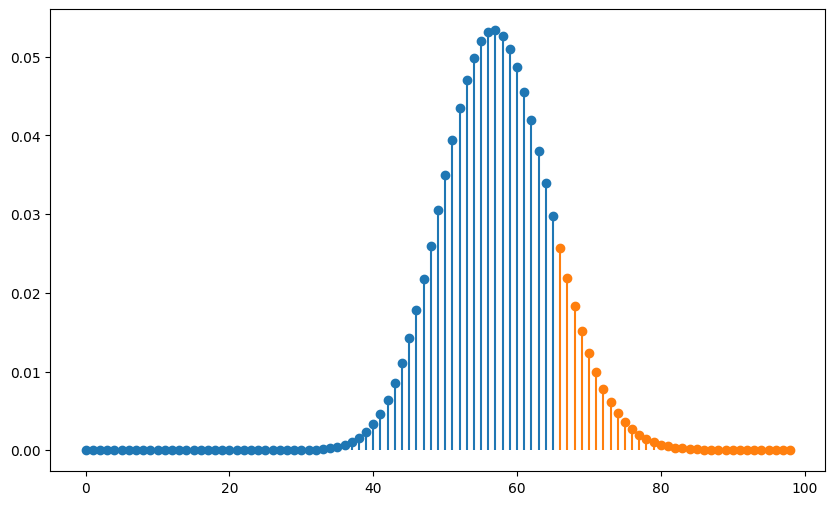

In [38]:
x0 = -2
myk = np.sum( x <= x0 )
p = norm.cdf(x0)

import matplotlib.pyplot as plt

k = np.arange(0, 99)

pmf_vals = binom(n,p).pmf(k)

plt.figure(figsize=(10, 6))
plt.vlines(k[k < myk], 0, pmf_vals[k < myk], colors="#1f77b4")
plt.scatter(k[k < myk], pmf_vals[k < myk], color="#1f77b4")
plt.vlines(k[k >= myk], 0, pmf_vals[k >= myk], colors="#ff7f0e")
plt.scatter(k[k >= myk], pmf_vals[k >= myk], color="#ff7f0e")
plt.show()

In [39]:
np.sum( pmf_vals[k >= myk] )

np.float64(0.13481237790127426)

We now aim to obtain the full empirical cumulative distribution function (CDF) using the sample estimator in Equation (4.10):  
$$\hat{F}_X(x) = \frac{1}{n} \sum_{i=0}^{n-1} \mathbb{I}_{X_i \leq x},$$  
where $\{ X_i \}_{i=0}^{n-1}$ are $n$ i.i.d. realizations of $X$.

We begin by defining a function that evaluates $\hat{F}_X( \cdot )$ at a given cutoff point, provided as an input together with the sample vector.

In [40]:
def F_hat_fct(myArray, cutoff):
  return np.sum( myArray <= cutoff )/len(myArray)

In [41]:
F_hat_fct(x, x0)

np.float64(0.026242544731610338)

In [42]:
myk/n

np.float64(0.026242544731610338)

We then evaluate $\hat{F}_X(\cdot)$ on a discretization of the empirical support of $X$, that is, a (typically equally spaced) discretization of the interval $[\min\{x_i\}, \max\{x_i\}]$.

For the sake of comparison, we also evaluate the CDF of the standard normal distribution, $\Phi(\cdot)$, at the same representative points.

In [43]:
min_x = min(x)
min_x

array([-8.56588245])

In [44]:
max_x = max(x)
max_x

array([8.34624767])

In [45]:
empirical_support = np.linspace(min_x, max_x, 100)
empirical_support

array([[-8.56588245],
       [-8.39505285],
       [-8.22422326],
       [-8.05339366],
       [-7.88256406],
       [-7.71173447],
       [-7.54090487],
       [-7.37007527],
       [-7.19924567],
       [-7.02841608],
       [-6.85758648],
       [-6.68675688],
       [-6.51592729],
       [-6.34509769],
       [-6.17426809],
       [-6.00343849],
       [-5.8326089 ],
       [-5.6617793 ],
       [-5.4909497 ],
       [-5.3201201 ],
       [-5.14929051],
       [-4.97846091],
       [-4.80763131],
       [-4.63680172],
       [-4.46597212],
       [-4.29514252],
       [-4.12431292],
       [-3.95348333],
       [-3.78265373],
       [-3.61182413],
       [-3.44099454],
       [-3.27016494],
       [-3.09933534],
       [-2.92850574],
       [-2.75767615],
       [-2.58684655],
       [-2.41601695],
       [-2.24518736],
       [-2.07435776],
       [-1.90352816],
       [-1.73269856],
       [-1.56186897],
       [-1.39103937],
       [-1.22020977],
       [-1.04938018],
       [-0

In [46]:
F_hat_vals = np.zeros(len(empirical_support))
Phi_vals = np.zeros(len(empirical_support))

for i in range(len(empirical_support)):
  F_hat_vals[i] = F_hat_fct(x, empirical_support[i])
  Phi_vals[i] = norm.cdf(empirical_support[i])

/tmp/ipykernel_34230/551651089.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Phi_vals[i] = norm.cdf(empirical_support[i])


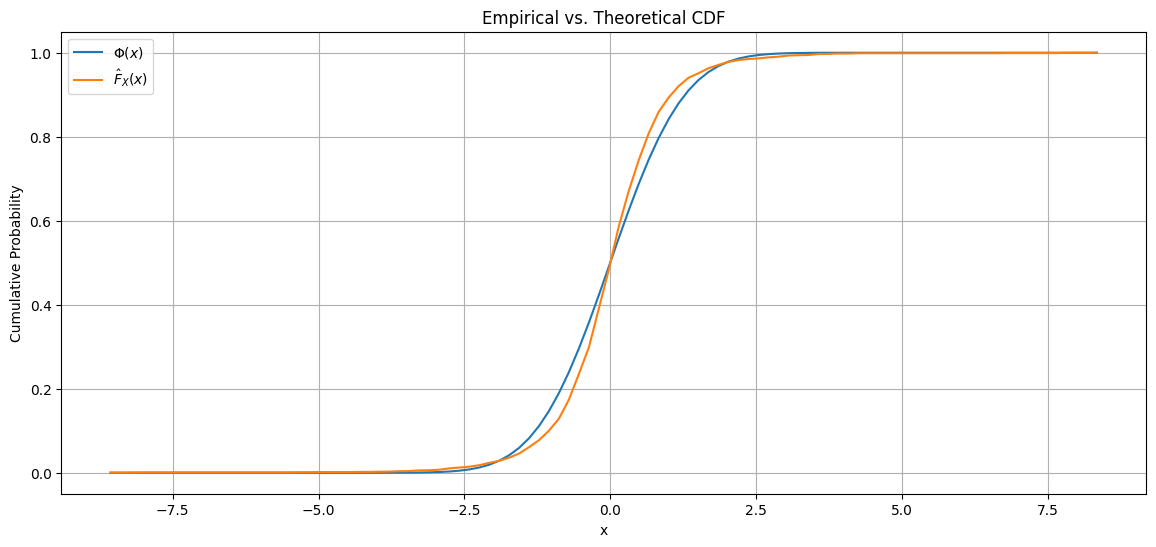

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.grid(True)

plt.plot(empirical_support, Phi_vals, label=r"$\Phi(x)$")
plt.plot(empirical_support, F_hat_vals, label=r"$\hat{F}_X(x)$")

plt.ylabel("Cumulative Probability")
plt.title("Empirical vs. Theoretical CDF")
plt.legend()
plt.xlabel("x")
plt.show()

From the analysis of the graph, we can see that, as shown in Figure 4.4 of the Lecture Notes, two notable crossing points emerge, $x_1 < 0 < x_2$, such that  
$$\hat{F}_X(x) \geq \Phi(x) \quad \text{or, equivalently,} \quad \hat{\Pr}[X \leq x] \geq \Pr[\mathcal{N}(0,1) \leq x],$$  
for all $x \leq x_1$, and  
$$\hat{F}_X(x) \leq \Phi(x) \quad \text{or, equivalently,} \quad \hat{\Pr}[X > x] \geq \Pr[\mathcal{N}(0,1) > x],$$  
for all $x \geq x_2$.

As is well known, additional insights can be obtained by analyzing the probability density function (PDF), whose approximate sample estimator is given in Equation (4.17) of the Lecture Notes:  
$$\hat{f}_X(x) \approx \frac{1}{2\varepsilon} \cdot \frac{1}{n} \sum_{i=0}^{n-1} \mathbb{I}_{x - \varepsilon \leq X_i \leq x + \varepsilon},$$  
where $\varepsilon > 0$ is small.

Note that $\hat{f}_X(\cdot)$ can equivalently be computed using the empirical estimator of the CDF by setting  
$$\hat{f}_X(x) \approx \frac{1}{2\varepsilon} \left( \hat{F}_X(x + \varepsilon) - \hat{F}_X(x - \varepsilon) \right).$$  

In what follows, we evaluate this function, along with the PDF of the standard normal distribution, $\phi(\cdot)$, at the same representative points of the empirical support as before, using an $\varepsilon$ value equal to half the discretization step of the empirical support.

In [48]:
epsilon = (empirical_support[1]-empirical_support[0])/2

f_hat_vals = np.zeros(len(empirical_support))
phi_vals = np.zeros(len(empirical_support))

for i in range(len(empirical_support)):
  f_hat_vals[i] = (F_hat_fct(x, empirical_support[i]+epsilon)-F_hat_fct(x, empirical_support[i]-epsilon))/(2*epsilon)
  phi_vals[i] = norm.pdf(empirical_support[i])

/tmp/ipykernel_34230/145962290.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f_hat_vals[i] = (F_hat_fct(x, empirical_support[i]+epsilon)-F_hat_fct(x, empirical_support[i]-epsilon))/(2*epsilon)
/tmp/ipykernel_34230/145962290.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  phi_vals[i] = norm.pdf(empirical_support[i])


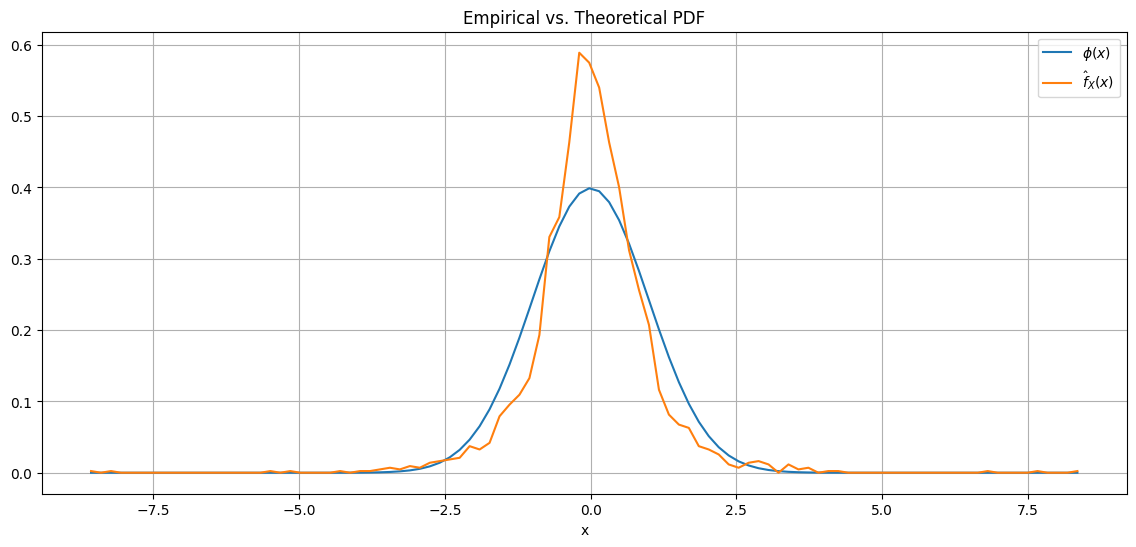

In [49]:
plt.figure(figsize=(14, 6))
plt.grid(True)

plt.plot(empirical_support, phi_vals, label=r"$\phi(x)$")
plt.plot(empirical_support, f_hat_vals, label=r"$\hat{f}_X(x)$")

plt.legend()
plt.title("Empirical vs. Theoretical PDF")
plt.xlabel("x")
plt.show()

By comparing the empirical and theoretical normal densities, we can identify four crossing points, $x_1 < x_2 < 0 < x_3 < x_4$, which reveal the classical stylized features of the (unconditional) distribution of equity log returns:
*   FAT TAILS, when $f_X(x) \geq \phi(x)$ for all $x \leq x_1$ and $x \geq x_4$;
*   THIN SHOULDERS, when $f_X(x) \leq \phi(x)$ for all $x_1 \leq x \leq x_2$ and $x_3 \leq x \leq x_4$;
*   TALL HEAD, when $f_X(x) \geq \phi(x)$ for all $x_2 \leq x \leq x_3$.

Notice that the estimated PDF coincides with the normalized histogram of the sample.

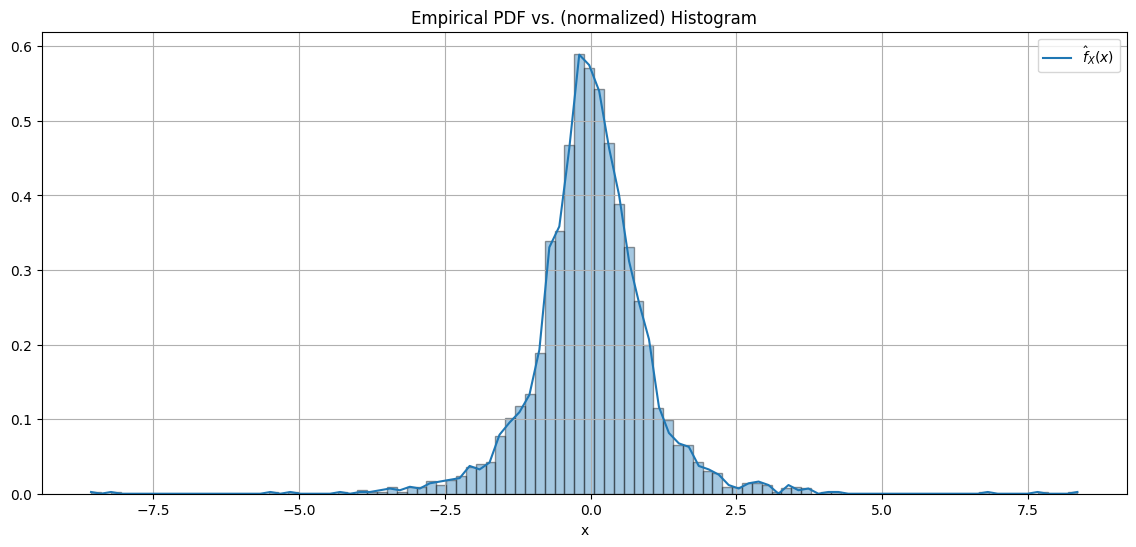

In [50]:
plt.figure(figsize=(14, 6))
plt.grid(True)

plt.plot(empirical_support, f_hat_vals, label=r"$\hat{f}_X(x)$")
plt.hist(x, bins=100, edgecolor="black", density=True, alpha=0.4, color="#1f77b4")

plt.legend()
plt.title("Empirical PDF vs. (normalized) Histogram")
plt.xlabel("x")
plt.show()

## BONUS 1: A formal normality test

The Jarque-Bera (JB) test is a goodness-of-fit test that assesses whether sample data have sample skewness and kurtosis compatible with the ones of a normal distribution.

The JB statistic measures the discrepancy of the sample skewness $S$ and kurtosis $K$ from the theoretical values and it is defined as
$$
JB = \frac{n}{6}\left(\hat{\text{skew}}[r_t^*]^2 + \frac{1}{4}(\hat{\text{kurt}}[r_t^*] - 3)^2\right),
$$
where $n$ is the sample size.

In [51]:
JB = n/6*(my_skew**2 + 0.25*(my_kurt-3)**2)
JB

np.float64(9674.872105970333)

Under the null hypothesis of normality, the statistic asymptotically follows a chi-squared distribution with two degrees of freedom.

Therefore, the $p$-value of the test can be computed as the probability that a chi-squared random variable with two degrees of freedom exceeds the observed value of the $JB$ statistic, that is,
$$
pvalJB = 1 - F_{\chi^2_2}(JB),
$$
where $F_{\chi^2_2}(\cdot)$ denotes the cumulative distribution function of the chi-squared distribution with two degrees of freedom.

As usual, the chi-squared distribution with $m$ degrees of freedom is available in `scipy.stats`.


In [52]:
from scipy.stats import chi2

pvalJB = 1-chi2(2).cdf(JB)
pvalJB

np.float64(0.0)

In fact, the entire test is available in `scipy.stats` as `jarque_bera`.

In [53]:
from scipy.stats import jarque_bera

stat_JB, p_JB = jarque_bera(x)
stat_JB

np.float64(9674.872105970333)

In [54]:
p_JB

np.float64(0.0)

## BONUS 2: The fit of the Student-t distribution

We now turn to the estimation of a Student-$t$ distribution, which proves to be a good proxy for the empirical distribution of the log returns under analysis.

In `scipy.stats`, this can be conveniently performed using the `.fit()` method (available for any other variable), which estimates the parameters of the chosen distribution via maximum likelihood estimation (MLE).

The main idea behind MLE is to determine the parameter values that maximize the probability (likelihood) of observing the realized sample. Formally, given a sample $\{ x_i \}_{i=0}^{n-1}$ and a parametric density $f_X(x; \boldsymbol{\theta})$, the likelihood function is defined as  
$$
\mathcal{L}(\boldsymbol{\theta}; x_0, \dots, x_{n-1}) = \prod_{i=0}^{n-1} f_X(x_i; \boldsymbol{\theta}),
$$  
where $\boldsymbol{\theta}$ denotes the vector of parameters to be estimated. The maximum likelihood estimator is then obtained by solving  
$$
\hat{\boldsymbol{\theta}} = \arg \max_{\boldsymbol{\theta}} \, \mathcal{L}(\boldsymbol{\theta}; x_0, \dots, x_{n-1}),
$$  
that is, by finding the parameter values that make the observed sample most likely under the assumed model.

In the case of the Student-$t$ distribution, these parameters are the degrees of freedom $\nu$, the location parameter $\mu$, and the scale parameter $\sigma$.

In [55]:
params = t.fit(x)
df, loc, scale = params
print(df, loc, scale)

3.33776906434223 0.002005589895656317 0.6519131583246803


It is worth noting that the MLE-based estimates of the location and scale parameters may differ from the corresponding sample mean and standard deviation. This occurs because maximum likelihood estimation jointly optimizes all parameters to best fit the assumed distribution, rather than matching individual sample moments, thus adjusting the estimates to account for the specific shape implied by the Student-$t$ model.


In [56]:
r.mean()

np.float64(0.0004398828977077566)

In [57]:
r.std()

np.float64(0.019571177882921415)

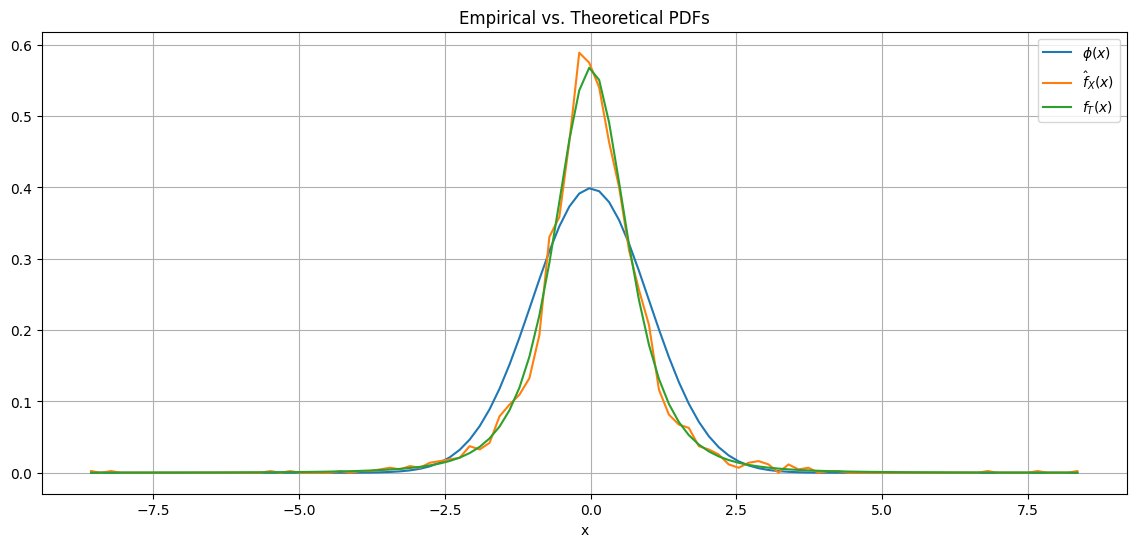

In [58]:
t_vals = t.pdf(empirical_support, df, loc=loc, scale=scale)

plt.figure(figsize=(14, 6))
plt.grid(True)

plt.plot(empirical_support, phi_vals, label=r"$\phi(x)$")
plt.plot(empirical_support, f_hat_vals, label=r"$\hat{f}_X(x)$")
plt.plot(empirical_support, t_vals, label=fr"$f_T(x)$")

plt.legend()
plt.title("Empirical vs. Theoretical PDFs")
plt.xlabel("x")
plt.show()